# 03a · How to trust a model — evaluating honestly

*The most important skill in ML is not training a model — it's knowing whether to believe it.*

> ⏱ **Runtime:** ~15 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** Al–Cu map (noisy, imbalanced on purpose)

### 🎯 What you'll learn
1. why one **train/test split** can mislead, and how **cross-validation** fixes it,
2. reading a **learning curve** (would more data help?),
3. **precision, recall, F1** and why **accuracy lies** under class imbalance,
4. **ROC** and **precision–recall** curves and their single-number summaries (AUC, AP).

### 🧭 What you need to know first
- Notebook **03** (a classifier; confusion matrix, recall) and **01a** (logistic regression).
- This is the 'how do I know my model is any good?' notebook — high value for beginners.

> 🧪 **Why the data looks harder here.** The Al–Cu phases are almost perfectly separable, which would
> make every metric a boring 1.0. So we deliberately (a) add measurement **noise** and (b) make one
> phase **rarer** (imbalance). Now the metrics actually teach you something — exactly the messy
> situation you meet with real data.

### Step 0 — set-up

Run the cell below first. In Jupyter you run a cell by clicking it and pressing **Shift + Enter**.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py` — that means the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
print("helpers loaded from:", mm.__file__)

helpers loaded from: C:\Users\edrossi.PERSONALE\Dropbox\Meca Nano Live tutorials\Tutorial1_repo_update\mecanano-ml-nanomechanics\src\mecanano_ml\__init__.py


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score)
rng = np.random.default_rng(0)

## 1 · A deliberately imperfect dataset

Two-phase labels from clustering, then noise + imbalance so the classifier is good but not perfect.

> ✅ **When you run the next cell, you should see:** the class balance (about 3:1) — the 'hard' phase is the rare, interesting one.

In [3]:
df = mm.load_map("alcu_2um")
lab = KMeans(2, n_init=10, random_state=0).fit_predict(StandardScaler().fit_transform(df[["H", "E"]].values))
hard = df.groupby(lab)["H"].median().idxmax()
yb = (lab == hard).astype(int)

# Make the hard phase rare (imbalance): keep all matrix, ~25% of the hard indents.
i0 = np.where(yb == 0)[0]; i1 = np.where(yb == 1)[0]
keep = np.concatenate([rng.choice(i0, 4500, replace=False),
                       rng.choice(i1, 1500, replace=False)])
rng.shuffle(keep)                                 # mix the classes so every subset has both
                                                  # (the learning curve takes ordered sub-slices)
X = StandardScaler().fit_transform(df[["H", "E", "HE"]].values[keep])
X = X + rng.normal(0, 1.4, X.shape)               # add noise so the classes overlap (realistic)
y = yb[keep]
print("class balance:", {0: int((y == 0).sum()), 1: int((y == 1).sum())})

class balance: {0: 4500, 1: 1500}


## 2 · One split can fool you → cross-validation

A single train/test split gives **one** accuracy — but a lucky (or unlucky) split can shift it. **Cross-
validation** splits the data several ways and averages, giving a mean **and** a spread you can trust.

> 🧠 **cross-validation** — split the data into k equal **folds**; train on k−1 and test on the held-out fold, rotating so every fold is tested once. Average the k scores.

> 🧠 **fold** — one of the k equal parts the data is split into for cross-validation.

> ✅ **When you run the next cell, you should see:** a single-split accuracy, then 5-fold CV accuracies with their **mean ± std** — the ± is the part a single split hides.

In [4]:
model = LogisticRegression(max_iter=1000)

# (a) one split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
model.fit(Xtr, ytr)
print("single-split accuracy:", round(model.score(Xte, yte), 3))

# (b) 5-fold cross-validation
cv = StratifiedKFold(5, shuffle=True, random_state=0)
scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
print("5-fold accuracies:", np.round(scores, 3))
print(f"cross-validated accuracy = {scores.mean():.3f} ± {scores.std():.3f}")

single-split accuracy: 0.848
5-fold accuracies: [0.849 0.842 0.851 0.848 0.861]
cross-validated accuracy = 0.850 ± 0.006


*🖼 **Figure.** The single split is just one of these numbers. The CV mean ± std is the honest headline figure — always report the spread, not a lucky single split.*

## 3 · Would more data help? The learning curve

A **learning curve** plots score vs training-set size. If the validation score is still climbing at
the right edge, more data would help; if train and validation have met on a plateau, they haven't.

> 🧠 **learning curve** — accuracy as a function of how many training examples you use, for both training and validation sets. Its shape diagnoses under/overfitting and whether more data would pay off.

> ✅ **When you run the next cell, you should see:** two curves (train, validation) rising and flattening as data grows, meeting on a plateau — here more data would give diminishing returns.

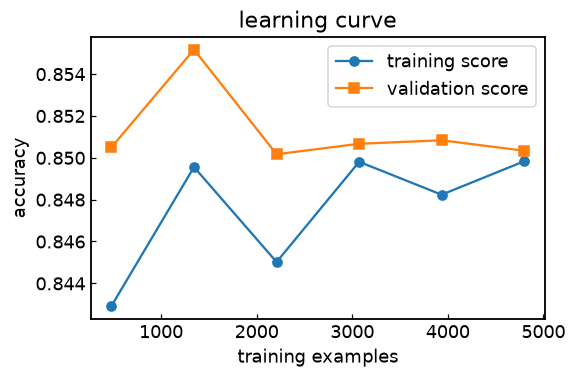

In [5]:
sizes, train_sc, val_sc = learning_curve(
    LogisticRegression(max_iter=1000), X, y, cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 6), scoring="accuracy")

fig, ax = plt.subplots(figsize=(5.4, 3.6))
ax.plot(sizes, train_sc.mean(1), "o-", label="training score")
ax.plot(sizes, val_sc.mean(1), "s-", label="validation score")
ax.set_xlabel("training examples"); ax.set_ylabel("accuracy"); ax.legend()
ax.set_title("learning curve"); fig.tight_layout()

*🖼 **Figure.** Training and validation scores converging on a plateau means the model has the data it needs — a bigger dataset wouldn't move the needle much. A large gap instead would signal overfitting.*

## 4 · Accuracy lies under imbalance → precision & recall

With a rare phase, a model that **always predicts 'matrix'** scores high accuracy while catching **none**
of the rare phase. **Precision** and **recall** expose that.

> 🧠 **precision** — of the indents the model *labelled* hard, what fraction really are? (Punishes false alarms.)

> 🧠 **recall** — of the indents that *are* hard, what fraction did the model catch? (Punishes misses.)

> 🧠 **F1 score** — the balance (harmonic mean) of precision and recall — one number when you care about both.

> ✅ **When you run the next cell, you should see:** a confusion matrix and a per-class report; note recall of the rare phase (class 1) is well below the overall accuracy — the gap accuracy hides.

              precision    recall  f1-score   support

      matrix       0.88      0.93      0.90      1350
        hard       0.73      0.61      0.67       450

    accuracy                           0.85      1800
   macro avg       0.81      0.77      0.78      1800
weighted avg       0.84      0.85      0.84      1800



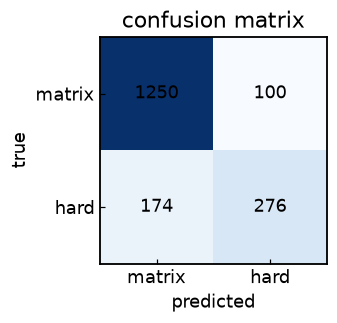

In [6]:
pred = model.predict(Xte)
cm = confusion_matrix(yte, pred)
fig, ax = plt.subplots(figsize=(3.4, 3.1)); ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["matrix", "hard"]); ax.set_yticks([0, 1], ["matrix", "hard"])
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("confusion matrix")
for (i, j), v in np.ndenumerate(cm): ax.text(j, i, f"{v}", ha="center", va="center")
fig.tight_layout()

print(classification_report(yte, pred, target_names=["matrix", "hard"]))

## 5 · Threshold-free views: ROC and precision–recall curves

A classifier outputs a **probability**; turning it into a label needs a **threshold** (default 0.5). The
**ROC** and **precision–recall** curves show performance across *all* thresholds at once, each summarised
by one number (**AUC**, **AP**).

> 🧠 **ROC curve / AUC** — true-positive rate vs false-positive rate as the threshold sweeps. AUC (area under it) is 1.0 for perfect, 0.5 for random.

> 🧠 **precision–recall curve / AP** — precision vs recall as the threshold sweeps — more informative than ROC when one class is rare. AP is its area (average precision).

> ✅ **When you run the next cell, you should see:** two curves: an ROC bowing toward the top-left (AUC ~0.9) and a PR curve, each with its area printed in the legend.

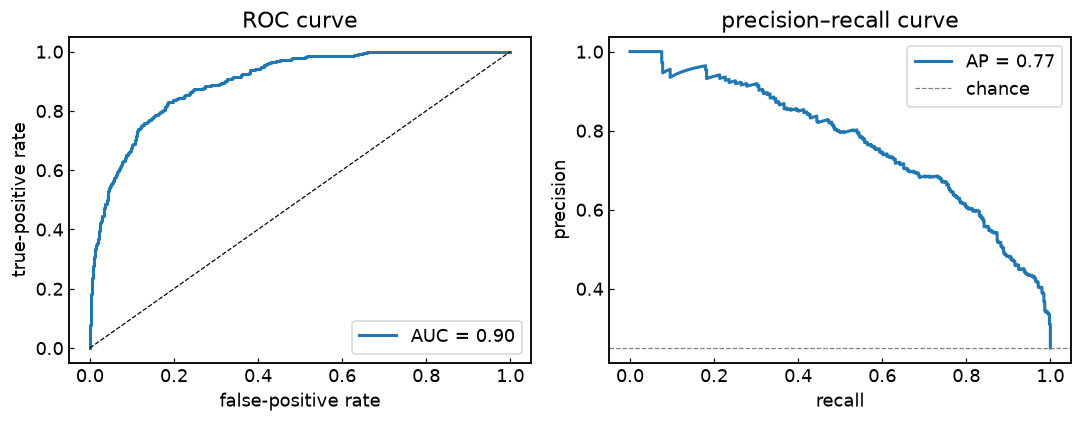

In [7]:
proba = model.predict_proba(Xte)[:, 1]            # probability of the rare 'hard' class

fpr, tpr, _ = roc_curve(yte, proba); auc = roc_auc_score(yte, proba)
prec, rec, _ = precision_recall_curve(yte, proba); ap = average_precision_score(yte, proba)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(fpr, tpr, lw=2, label=f"AUC = {auc:.2f}"); ax[0].plot([0, 1], [0, 1], "k--", lw=.8)
ax[0].set_xlabel("false-positive rate"); ax[0].set_ylabel("true-positive rate")
ax[0].set_title("ROC curve"); ax[0].legend()
ax[1].plot(rec, prec, lw=2, label=f"AP = {ap:.2f}")
ax[1].axhline((yte == 1).mean(), ls="--", c="grey", lw=.8, label="chance")
ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision"); ax[1].set_title("precision–recall curve"); ax[1].legend()
fig.tight_layout()

*🖼 **Figure.** ROC (left) bowing toward the top-left corner and the PR curve (right) sitting well above the grey chance line both say: a good, though imperfect, classifier. For a rare class, trust the PR curve more than accuracy.*

## ✅ Recap
- Report **cross-validated** scores with their spread, not one lucky split.
- A **learning curve** tells you whether more data would help.
- Under imbalance, **accuracy lies** — read **precision/recall/F1**, the **confusion matrix**, and the **PR curve**; **ROC/AUC** summarise all thresholds.

## 🔧 Try it yourself
Small changes teach the most. Try these (re-run the cell after each):
1. Lower the noise (`0.0` instead of `1.4`) and re-run. Watch every metric shoot toward 1.0 — the 'too easy' regime that teaches nothing.
2. Change the decision threshold: label hard when `proba > 0.3` instead of 0.5. How do precision and recall trade off?
3. Swap `LogisticRegression` for a `RandomForestClassifier`. Do the CV mean and AUC improve?

## 🩹 Common errors & fixes
- **`ValueError: multiclass ...` in roc_curve** → ROC here assumes two classes and a probability; keep it binary.
- **CV score differs from the single split** → that's the whole point; the CV mean ± std is the trustworthy number.
- **Precision/recall undefined warning** → happens if a class is never predicted; lower the threshold or rebalance.

---
**Next:** **`04_curve_as_image_cnn.ipynb`** and **`04a_1d_cnn_on_curves.ipynb`** — evaluate deep models with exactly these tools.